# Exploring knowledge graphs visually
this notebook serves as a documentation for motivating the design choices made in the present commit. It shows intermediate results and the effects of the applied changes.
The code is not meant to be read or reused, please just follow the markdown descriptions and the cell outputs.
It will be removed in the next commit in order to not clutter the main repo.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import display
from matplotlib.patches import Patch



The graph was generated using Iggytop (no changes made) only with the TCR3D database adapter and saved using the Biocypher to_networkx() function

In [2]:

# Load the graph from the .graphml file
graph_path = "/cluster/home/dego/.cache/iggytop_tcr3d/iggytop_knowledge_graph.graphml"
G = nx.read_graphml(graph_path)


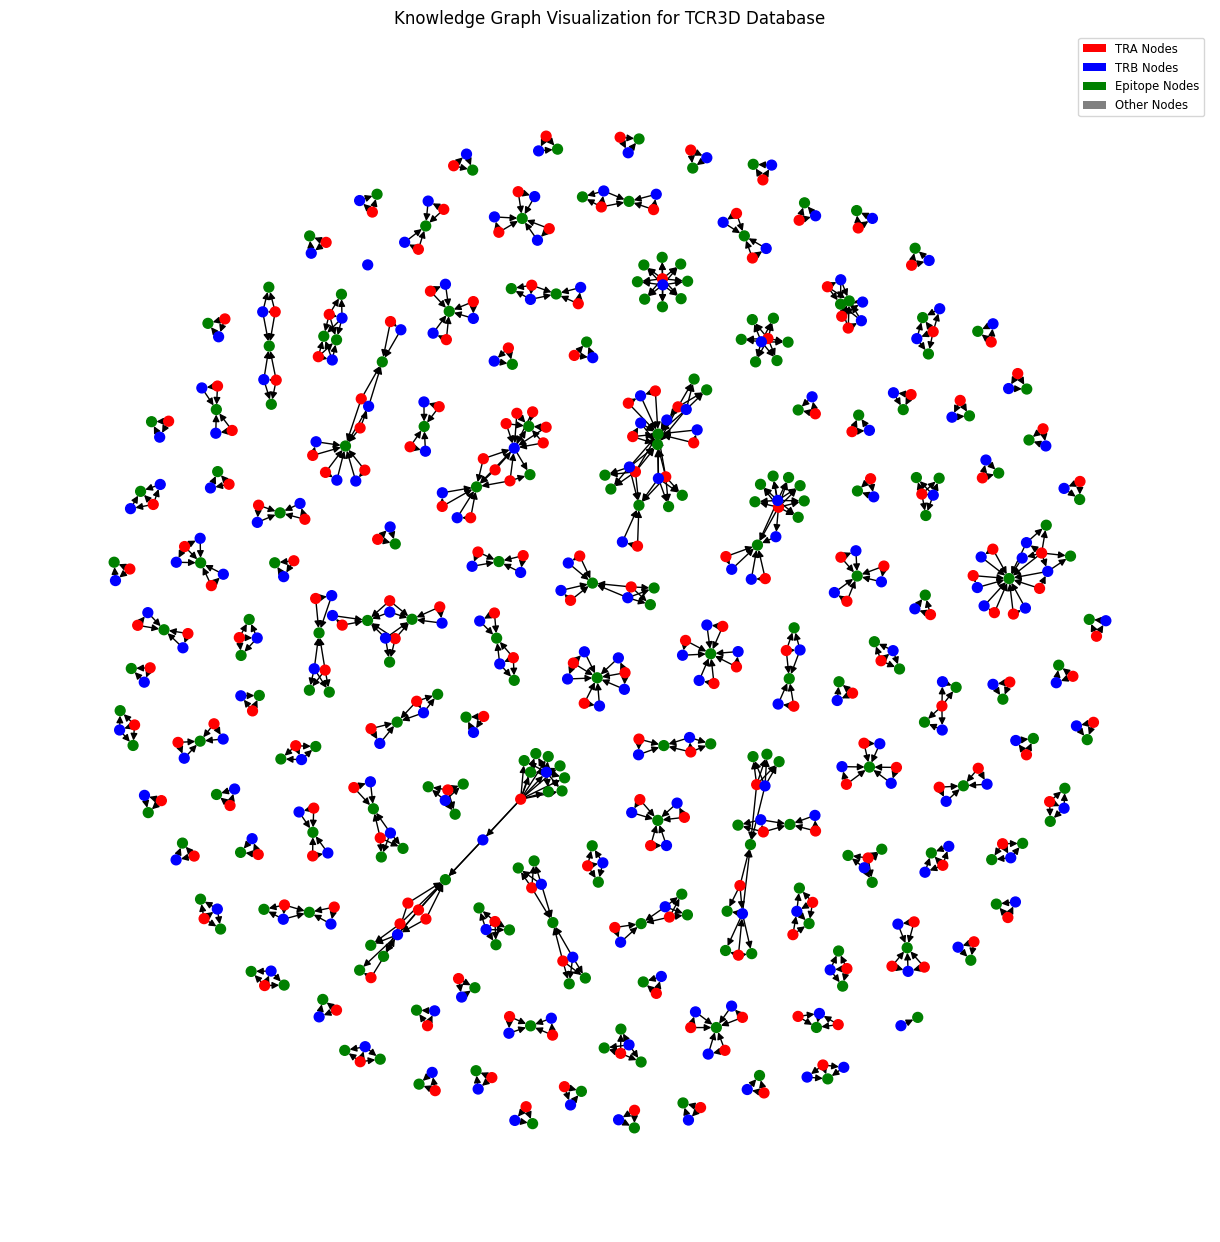

In [3]:
# Draw the graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G)  # Position nodes using the spring layout
# Assign colors based on node labels
node_colors = []
for node in G.nodes:
    if node.startswith("tra"):
        node_colors.append("red")
    elif node.startswith("trb"):
        node_colors.append("blue")
    elif node.startswith("epitope"):
        node_colors.append("green")
    else:
        node_colors.append("grey")

# Pass the node_colors to the draw function
nx.draw(
    G, pos, with_labels=False, node_size=50, node_color=node_colors, font_size=8, font_color="black"
)
# Add a legend for the node colors

legend_elements = [
    Patch(facecolor='red', label='TRA Nodes'),
    Patch(facecolor='blue', label='TRB Nodes'),
    Patch(facecolor='green', label='Epitope Nodes'),
    Patch(facecolor='grey', label='Other Nodes')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize='small')
plt.title("Knowledge Graph Visualization for TCR3D Database")
plt.show()

In [4]:
# Find the number of weakly connected components in the directed graph
num_components = nx.number_weakly_connected_components(G)
print(f"Number of separate subgraphs: {num_components}")

Number of separate subgraphs: 127


We observe two interesting subgraphs: a disconnected node and a trb-epitope without tra:

In [5]:
# Find nodes without edges (isolated nodes)
isolated_nodes = [node for node in G.nodes if G.degree(node) == 0]

# Print the labels of isolated nodes
print("Isolated nodes (nodes without edges):")
for node in isolated_nodes:
    print(node)

Isolated nodes (nodes without edges):
trb:CASSFTDTQYF:TRBV6-2


In [6]:
# Iterate through weakly connected components
for component in nx.weakly_connected_components(G):
    subgraph = G.subgraph(component)
    if subgraph.number_of_edges() == 1:
        # Get the single edge in the subgraph
        edge = list(subgraph.edges(data=True))[0]
        edge_label = edge[2]  # Edge attributes
        print("Edge label of the subgraph with only one edge:", edge_label)
        break

Edge label of the subgraph with only one edge: {'relationship_id': 'trb:CASSLDWVGDGERQYF:TRBV11-2-epitope:seq:SLSNRLYYL', 'relationship_label': 't cell receptor sequence to epitope association'}


# Isolated node:
I tracked down the isolated node and found that it has a very similar entry in the db, they only differ in trb:v_gene

In [7]:
# Load the data from the specified file
file_path = "~/.cache/iggytop_tcr3d/tcr3d_latest/tcr_complexes_data.tsv"
data = pd.read_csv(file_path, sep="\t")

# Filter rows where CDR3_beta equals 'CASSFTDTQYF'
filtered_rows = data[data["CDR3_beta"] == "CASSFTDTQYF"]

# Use the display function to show the DataFrame with all columns visible
display(filtered_rows.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
))

,PDB_ID,TCR_complex,TCR_name,TCR_organism,Epitope,MHC_allele,TRAV_gene,TRBV_gene,CDR1_alpha,CDR2_alpha,CDR3_alpha,CDR1_beta,CDR2_beta,CDR3_beta,Docking_angle,Incident_angle,Buried_surface_area,Shape_complementarity,Release_date,Resolution,Pubmed
283,7pbc,CLASSI,c796,Human,GLYDGMEHL,HLA-A*02,TRAV12-2,TRBV6-3,TYSDRGSQSFF,MSIYSNGDK,CAVRGTGRRALTF,AQDMNHDYMY,HYSVGEGTTA,CASSFTDTQYF,30.700000,9.900000,2026.800000,0.670000,2022-08-03,2.040000,35851311.000000
285,7pdw,CLASSI,c728,Human,GLYDGMEHL,HLA-A*02,TRAV12-2,TRBV6-2,TYSDRGSQSFF,MSIYSNGDK,CAVRGTGRRALTF,AQDMNHEYMY,HYSVGEGTTA,CASSFTDTQYF,33.200000,10.900000,2048.800000,0.660000,2022-08-03,1.820000,35851311.000000


To solve this, we notice that the edges are deduplicated before considering the V-gene, therefore only one of the edges is kept and the trb node is left on its own.

To solve this i removed the deduplication in base_adapter > generate_edges_from_table()

Generate the resulting graph and see that the issue is solved:

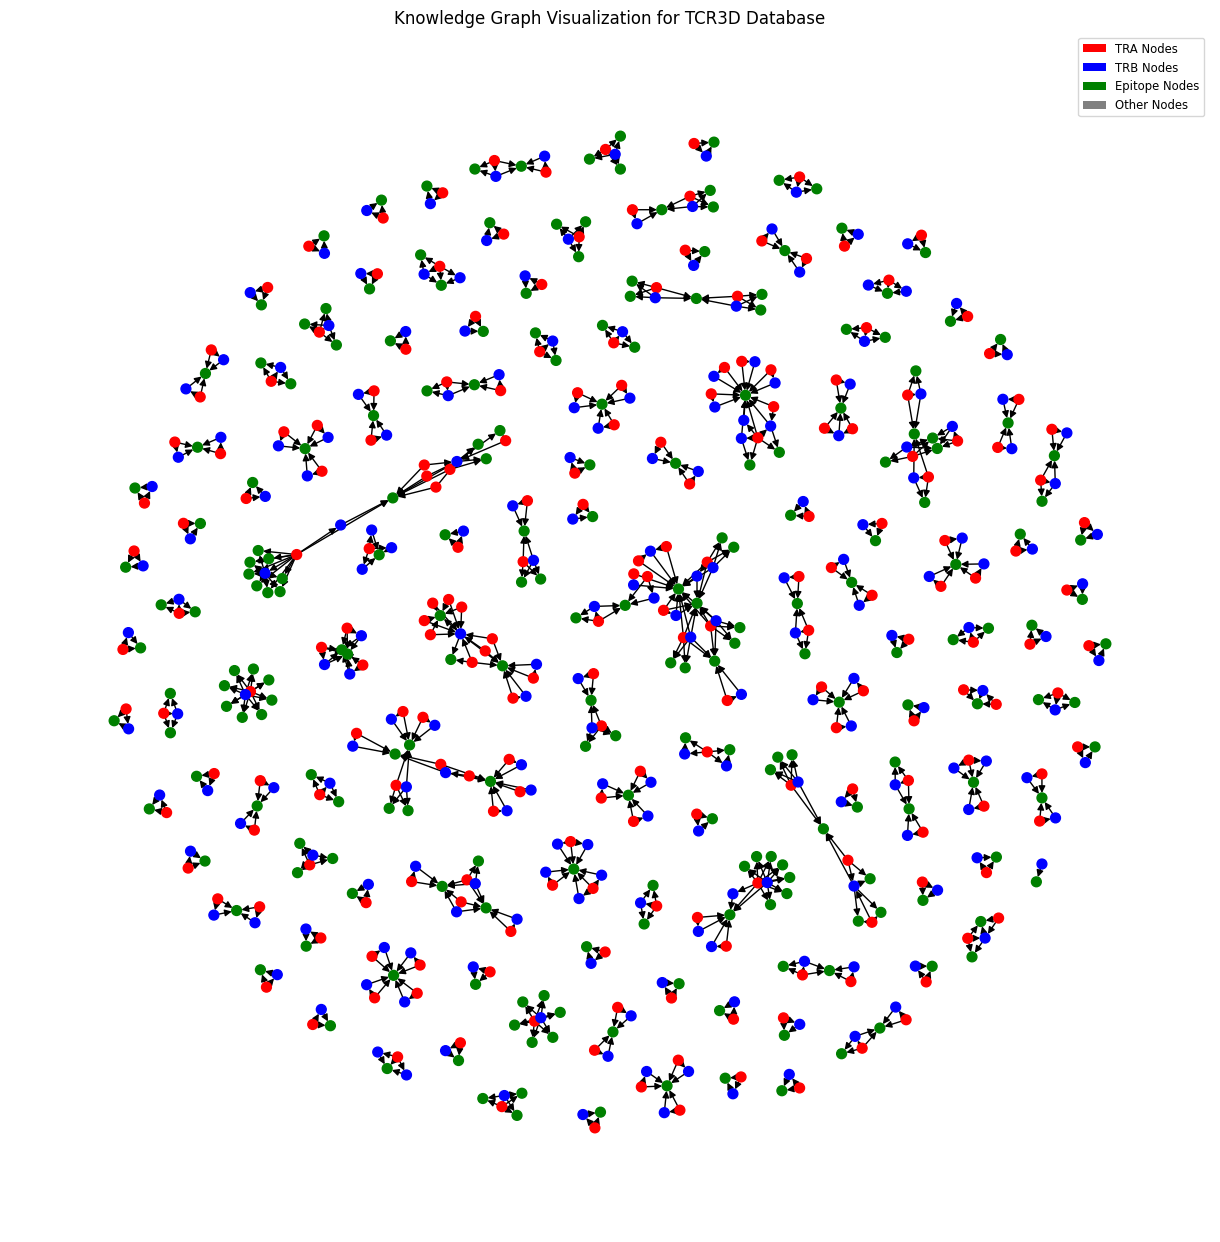

In [8]:

# Load the graph from the .graphml file
graph_path_v = "/cluster/home/dego/.cache/iggytop_tcr3d/iggytop_knowledge_graph_vgene.graphml"
Gv = nx.read_graphml(graph_path_v)

# Draw the graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(Gv)  # Position nodes using the spring layout

node_colors_v = []
for node in Gv.nodes:
    if node.startswith("tra"):
        node_colors_v.append("red")
    elif node.startswith("trb"):
        node_colors_v.append("blue")
    elif node.startswith("epitope"):
        node_colors_v.append("green")
    else:
        node_colors_v.append("grey")

# Pass the node_colors to the draw function
nx.draw(
    Gv, pos, with_labels=False, node_size=50, node_color=node_colors_v, font_size=8, font_color="black"
)
# Add a legend for the node colors

legend_elements = [
    Patch(facecolor='red', label='TRA Nodes'),
    Patch(facecolor='blue', label='TRB Nodes'),
    Patch(facecolor='green', label='Epitope Nodes'),
    Patch(facecolor='grey', label='Other Nodes')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize='small')
plt.title("Knowledge Graph Visualization for TCR3D Database")
plt.show()


In [10]:
# Find nodes without edges (isolated nodes)
isolated_nodes = [node for node in Gv.nodes if Gv.degree(node) == 0]

# Print the labels of isolated nodes
print("Isolated nodes (nodes without edges):")
if isolated_nodes:
    for node in isolated_nodes:
        print(node)
else:
    print("No isolated nodes found.")

Isolated nodes (nodes without edges):
No isolated nodes found.


We see that the subgraph without tra chain is still there

In [11]:
# Iterate through weakly connected components
for component in nx.weakly_connected_components(Gv):
    subgraph = Gv.subgraph(component)
    if subgraph.number_of_edges() == 1:
        # Get the single edge in the subgraph
        edge = list(subgraph.edges(data=True))[0]
        edge_label = edge[2]  # Edge attributes
        print("Edge label of the subgraph with only one edge:", edge_label)
        break

Edge label of the subgraph with only one edge: {'relationship_id': 'trb:CASSLDWVGDGERQYF:TRBV11-2-epitope:seq:SLSNRLYYL', 'relationship_label': 't cell receptor sequence to epitope association'}


The change does not affect the number of nodes in the graph

In [12]:
num_nodes = G.number_of_nodes()
num_nodes_v = Gv.number_of_nodes()
print(f"Number of nodes in the original graph: {num_nodes}")
print(f"Number of nodes in the graph with v_gene as node identifier: {num_nodes}")

Number of nodes in the original graph: 651
Number of nodes in the graph with v_gene as node identifier: 651


the number of nodes stays the same as the V-gene is added to the labels (later used by the deduplicator) by default.

This is not the case for edges, the base adapter originally deduplicated edges based on the given unique columns (in _generate_edges_from_table)
therefore, adding the v-gene results in more edges.


In [13]:
num_edges_G = G.number_of_edges()
num_edges_Gv = Gv.number_of_edges()

print(f"Number of edges in G: {num_edges_G}")
print(f"Number of edges in Gv: {num_edges_Gv}")

Number of edges in G: 863
Number of edges in Gv: 865


we can check which edges these were and confirm that these were the ones we were looking for

In [29]:
for u, v, data in Gv.edges(data=True):
    if not G.has_edge(u, v):
        print("Edge found in Gv but not in G:", (u, v, data))



Edge found in Gv but not in G: ('tra:CAVRGTGRRALTF:TRAV12-2', 'trb:CASSFTDTQYF:TRBV6-2', {'relationship_id': 'tra:CAVRGTGRRALTF:TRAV12-2-trb:CASSFTDTQYF:TRBV6-2', 'relationship_label': 'alpha sequence to beta sequence association'})
Edge found in Gv but not in G: ('trb:CASSFTDTQYF:TRBV6-2', 'epitope:iedb:189401', {'relationship_id': 'trb:CASSFTDTQYF:TRBV6-2-epitope:iedb:189401', 'relationship_label': 't cell receptor sequence to epitope association'})


# Missing TRA
Lets find the row in the original tcr3d db

In [30]:
# Load the data from the specified file
file_path = "~/.cache/iggytop_tcr3d/tcr3d_latest/tcr_complexes_data.tsv"
data = pd.read_csv(file_path, sep="\t")

# Filter rows where CDR3_beta equals 'CASSFTDTQYF'
filtered_rows = data[data["CDR3_beta"] == "CASSLDWVGDGERQYF"]

# Use the display function to show the DataFrame with all columns visible
display(filtered_rows.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
))

,PDB_ID,TCR_complex,TCR_name,TCR_organism,Epitope,MHC_allele,TRAV_gene,TRBV_gene,CDR1_alpha,CDR2_alpha,CDR3_alpha,CDR1_beta,CDR2_beta,CDR3_beta,Docking_angle,Incident_angle,Buried_surface_area,Shape_complementarity,Release_date,Resolution,Pubmed
356,9gv6,CLASSI,TCR-C,Human,SLSNRLYYL,HLA-A*02,nan,TRBV11-2,nan,nan,nan,NPISGHGTLY,IQFHNNGVVDD,CASSLDWVGDGERQYF,61.800000,28.200000,1696.100000,0.660000,2025-04-23,2.770000,40154610.000000


we find that the db does not contain a TRA and therefore this is expected

# validate for NeoTCR
in order to check if the changes results in some unexpected behaviour we chack the effect on the NEeoTCR db which is also small enough to visualize:

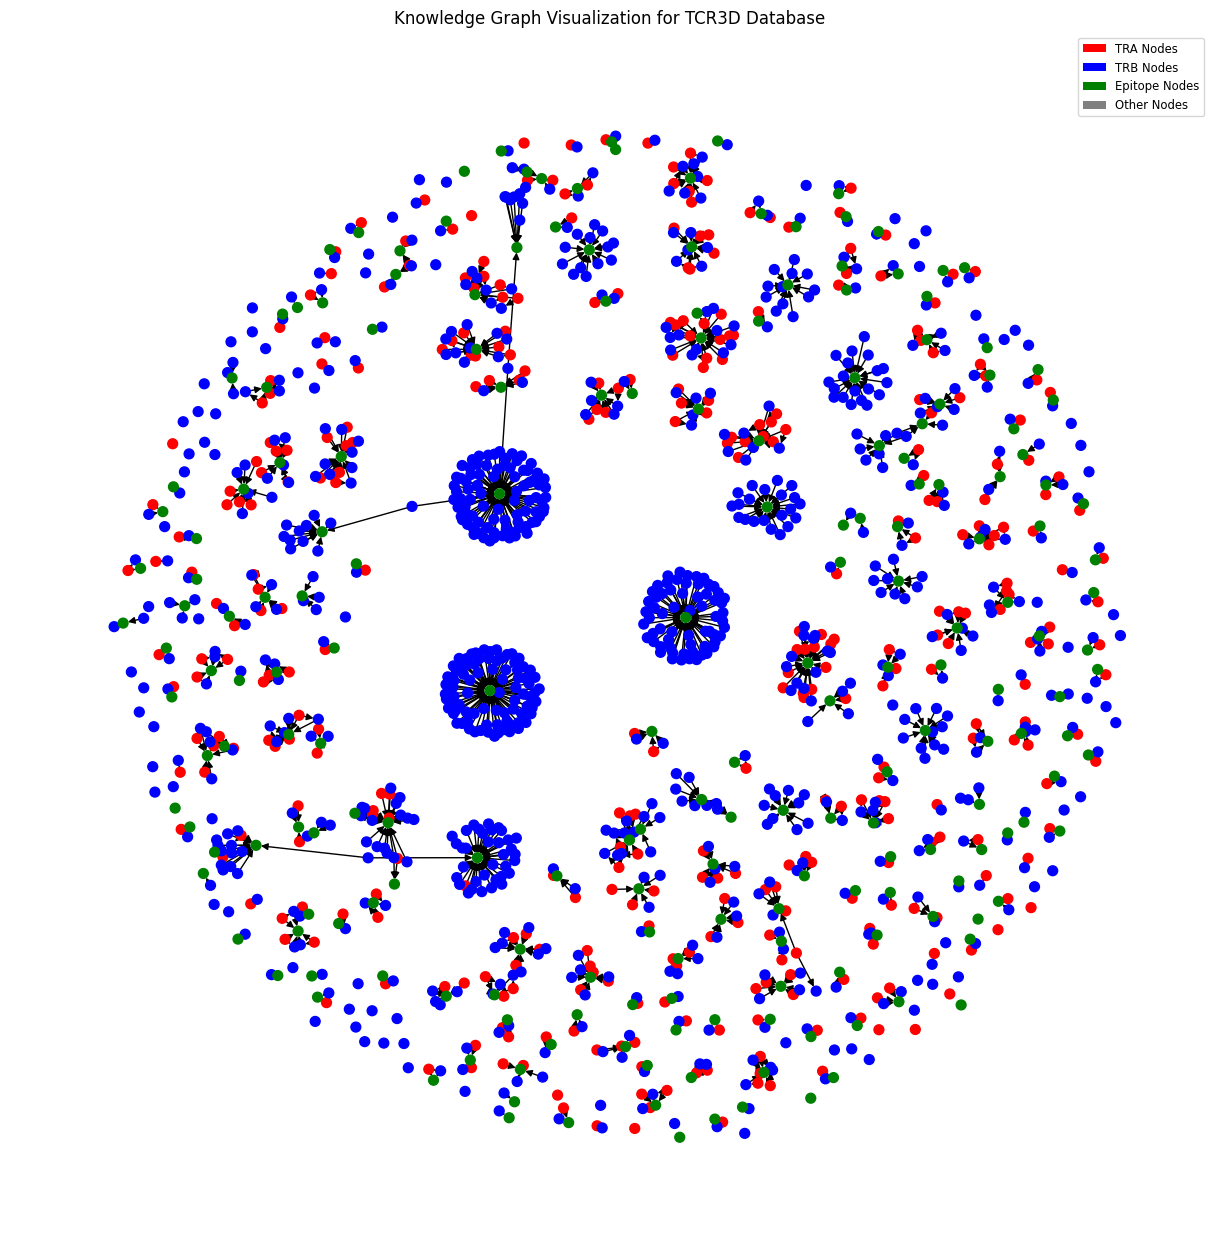

In [32]:
# Load the graph from the .graphml file
graph_path_n = "/cluster/home/dego/.cache/iggytop_neotcr/iggytop_knowledge_graph.graphml"
Gn = nx.read_graphml(graph_path_n)

# Draw the graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(Gn)  # Position nodes using the spring layout

node_colors_n = []
for node in Gn.nodes:
    if node.startswith("tra"):
        node_colors_n.append("red")
    elif node.startswith("trb"):
        node_colors_n.append("blue")
    elif node.startswith("epitope"):
        node_colors_n.append("green")
    else:
        node_colors_n.append("grey")

# Pass the node_colors to the draw function
nx.draw(
    Gn, pos, with_labels=False, node_size=50, node_color=node_colors_n, font_size=8, font_color="black"
)

plt.legend(handles=legend_elements, loc='upper right', fontsize='small')
plt.title("Knowledge Graph Visualization for TCR3D Database")
plt.show()

In [43]:
nx.number_weakly_connected_components(Gn)

306

 many tcr's are not associated with an epitope as the database sometimes only reportes the antigen but not the epitope (see below). 
 
 Filter out the nodes without edges and plot again

In [42]:
# Load the data from the specified file
file_path = "/cluster/home/dego/datasets/IggyTop/develop-igT/NeoTCR_data-20221220.xlsx"
data = pd.read_excel(file_path, sheet_name="All")
    
data.iloc[500]


Tumor                  T large granular lymphocyte leukemia
Antigen                                              STAT5B
Amino Acid Exchange                                   N642H
Neoepitope                                             n.a.
TRAV                                                   n.a.
TRAJ                                                   n.a.
TRA_CDR3                                               n.a.
TRBV                                              TRBV18*01
TRBJ                                             TRBJ2-7*01
TRB_CDR3                                      CASSPDASYEQYF
Cell Type                                              n.a.
HLA Allele                                             n.a.
Source                                              Patient
PubMed ID                                    PMID: 35210405
Name: 500, dtype: object

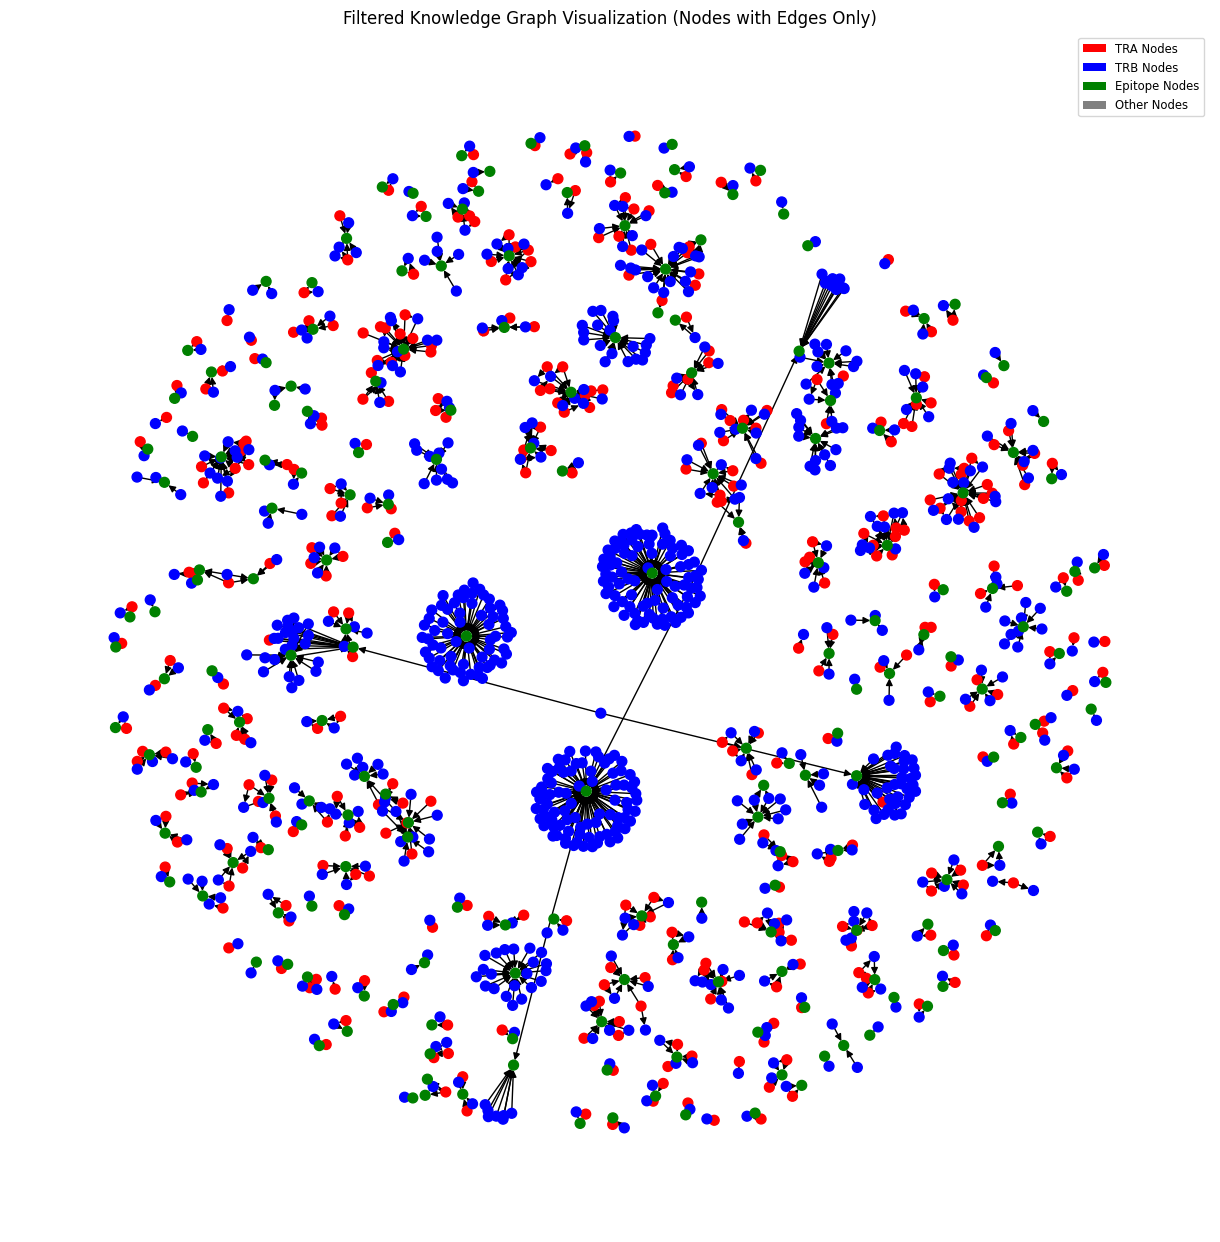

In [33]:
# Remove nodes without edges
nodes_with_edges = [node for node in Gn.nodes if Gn.degree(node) > 0]
filtered_graph_n = Gn.subgraph(nodes_with_edges)

# Draw the filtered graph
plt.figure(figsize=(12, 12))
pos_filtered = nx.spring_layout(filtered_graph_n)  # Position nodes using the spring layout
# Assign colors based on node labels
filtered_node_colors = []
for node in filtered_graph_n.nodes:
    if node.startswith("tra"):
        filtered_node_colors.append("red")
    elif node.startswith("trb"):
        filtered_node_colors.append("blue")
    elif node.startswith("epitope"):
        filtered_node_colors.append("green")
    else:
        filtered_node_colors.append("grey")

# Pass the filtered_node_colors to the draw function
nx.draw(
    filtered_graph_n, pos_filtered, with_labels=False, node_size=50, node_color=filtered_node_colors, font_size=8, font_color="black"
)

# Add a legend for the node colors
plt.legend(handles=legend_elements, loc='upper right', fontsize='small')
plt.title("Filtered Knowledge Graph Visualization (Nodes with Edges Only)")
plt.show()

In [34]:
# Count the number of disconnected subgraphs in the filtered graph
num_disconnected_subgraphs = nx.number_weakly_connected_components(filtered_graph_n)
print(f"Number of disconnected subgraphs after filtering: {num_disconnected_subgraphs}")

Number of disconnected subgraphs after filtering: 208


## After adding v_gene as identifyer:

In [44]:
# Load the graph from the .graphml file
graph_path_nv = "/cluster/home/dego/.cache/iggytop_neotcr/iggytop_knowledge_graph_vgene.graphml"
Gnv = nx.read_graphml(graph_path_nv)

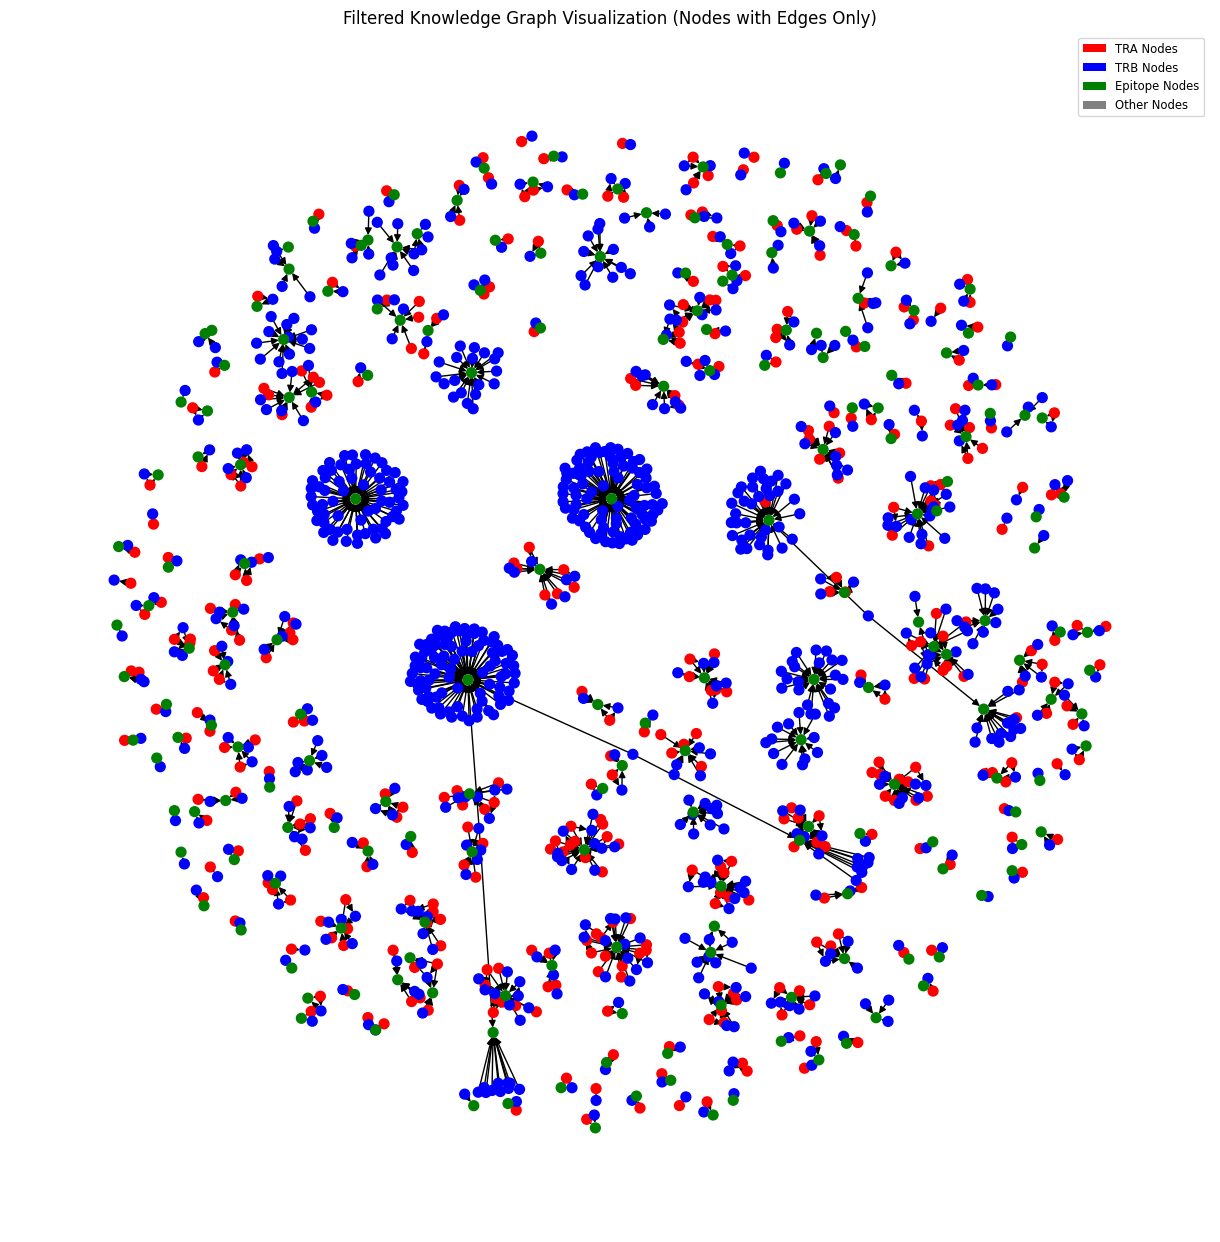

In [45]:
# Remove nodes without edges
nodes_with_edges = [node for node in Gnv.nodes if Gnv.degree(node) > 0]
filtered_graph_v = Gnv.subgraph(nodes_with_edges)

# Draw the filtered graph
plt.figure(figsize=(12, 12))
pos_filtered_v = nx.spring_layout(filtered_graph_v)  # Position nodes using the spring layout
# Assign colors based on node labels
filtered_node_colors = []
for node in filtered_graph_v.nodes:
    if node.startswith("tra"):
        filtered_node_colors.append("red")
    elif node.startswith("trb"):
        filtered_node_colors.append("blue")
    elif node.startswith("epitope"):
        filtered_node_colors.append("green")
    else:
        filtered_node_colors.append("grey")

# Pass the filtered_node_colors to the draw function
nx.draw(
    filtered_graph_v, pos_filtered_v, with_labels=False, node_size=50, node_color=filtered_node_colors, font_size=8, font_color="black"
)

# Add a legend for the node colors
plt.legend(handles=legend_elements, loc='upper right', fontsize='small')
plt.title("Filtered Knowledge Graph Visualization (Nodes with Edges Only)")
plt.show()

In [46]:
# Count the number of nodes in the graph
num_nodes_n = Gn.number_of_nodes()
num_nodes_nv = Gnv.number_of_nodes()
print(f"Number of nodes in Gn: {num_nodes_n}")
print(f"Number of nodes in Gnv: {num_nodes_nv}")

Number of nodes in Gn: 1502
Number of nodes in Gnv: 1502


In [47]:

# Count the number of edges in the graph
num_edges_n = Gn.number_of_edges()
num_edges_nv = Gnv.number_of_edges()
print(f"Number of edges in Gn: {num_edges_n}")
print(f"Number of edges in Gnv: {num_edges_nv}")

Number of edges in Gn: 1552
Number of edges in Gnv: 1585


In [48]:
# Count the number of disconnected subgraphs in the filtered graph
num_disconnected_subgraphs_v = nx.number_weakly_connected_components(filtered_graph_v)
print(f"Number of disconnected subgraphs after filtering: {num_disconnected_subgraphs_v}")

Number of disconnected subgraphs after filtering: 209


## Other databases
The other databases are very large and therefore harder to plot